In [1]:
import sys
import importlib
from pathlib import Path

# go from ...\docs\tutorials up two levels to the repo root (...\darkgreybox)
repo_root = Path.cwd().parents[1]
sys.path.insert(0, str(repo_root))
importlib.invalidate_caches()


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold
from statsmodels.graphics.tsaplots import plot_pacf

from darkgreybox.models import TiTmxvCN2R2C
from darkgreybox.fit import darkgreyfit
from docs.tutorials.util.plot import plot
from docs.tutorials.util.error import rmse

2026-01-18 16:05:54,225 darkgreybox  INFO     Logging enabled...


## Demo Notebook 04 - DarkGreyFit

This notebook demonstrates the usage of the `DarkGreyBox` models via fitting them with `DarkGreyFit`, setting up and evaluating multiple pipelines at once.


Our temporal resolution is 1 hour

In [2]:
# the duration of a record (in seconds - 5 minutes)
rec_duration = 5/60

Read some demo data.  
* Ph: Heating system power output
* Ta: Ambient temperature
* Ti: Internal temperature

We are also setting a set of custom fields in our input data: `Ti0`, `Th0` and `Te0`. These fields define the initial conditions for `Ti`, `Th` and `Te` for each record of the input data respectively. E.g. if a sub-model is trained based on the 10-20 records of the training data, the initial conditions for the above params will be set by the 10. record of the input data. 

Note: This demo data is intentionally far from ideal and particularly challenging to model with low errors. It is taken from a building where there are many factors influencing the heat dynamics of the building that are not accounted for in the modelling (solar gains, passive gains, hot water demand, gas use in the canteen etc.). The time period is relatively short to maintain a reasonable solution time for the demo. However, it includes an also challenging holiday period when the heating system is shut down.

In [3]:
input_df = pd.read_csv('./data/general_data_csv_V2_cleaned.csv', index_col=0, parse_dates=True)

input_df['Ti'] = input_df['R01_06_TRU01']
input_df['Q'] = input_df['R01_06_FCI01']
input_df['MVV'] = input_df['R01_06_MVV01']
input_df['Ta'] = input_df['HTR9_VES01_TUD01']
input_df['Gk'] = input_df['HTR9_VES01_SI01']
input_df['svent'] = input_df['HTR9_VEN02_Status']
input_df['Tfor'] = input_df['HTRK_RAD01_TR02']
input_df['C'] = input_df['R01_06_CO201']

A_w = 10    # m²
g = 0.35    # total solar energy transmittance of the glazing 
S = 20      # m²
V0 = 2.5*S   # m³
E0 = 0.016   # m³/h
C_out0 = 400 # ppm

# Compute derived columns
input_df['N'] = input_df['Q'] / E0 * (input_df['C'] - C_out0) / 10**6
input_df['Q_vent'] = input_df['svent'] * 1.2 * 1000 * input_df['Q'] * (20 - input_df['Ti']) / 3600
input_df['Q_solar'] = g * A_w * input_df['Gk']
input_df['ACH'] = input_df['Q'] / V0

# Set initial conditions
input_df['Ti0'] = input_df['Ti']
input_df['Th0'] = input_df['Ti']
input_df['xv0'] = input_df['MVV'] / 100
input_df['C0'] = input_df['C']
input_df['N0'] = input_df['N']

input_X = input_df[['Ta', 'Tfor', 'Q_vent', 'Q_solar', 'MVV', 'ACH', 'Ti0', 'Th0', 'xv0', 'C0', 'N0']]
input_y = input_df['Ti']


print(f'Input X shape: {input_X.shape}, input y shape: {input_y.shape}')

Input X shape: (34551, 11), input y shape: (34551,)


In [4]:
X_train, X_test, y_train, y_test = train_test_split(input_X, input_y, test_size=0.2, shuffle=False)

print(f'Train: X shape: {X_train.shape}, y shape: {y_train.shape}')
print(f'Test: X shape: {X_test.shape}, y shape: {y_test.shape}')

Train: X shape: (27640, 11), y shape: (27640,)
Test: X shape: (6911, 11), y shape: (6911,)


Set up the model training parameters for each model instance that we want to spin up in the pipeline.  

The `Ti0` param is the initial condition for the internal temperature at t=0 - this is set to the first record of `X_train['Ti0']` as described above and is fixed, hence `vary: False`.  

The `Te0` param is the initial condition for the building envelope temperature at t=0 - - this is set to the first record of `X_train['Te0']` as described above and is NOT fixed, hence `vary: True`.  

The `Th0` param is the initial condition for the heating system temperature at t=0 - - this is set to the first record of `X_train['Th0']` as described above and is NOT fixed, hence `vary: True`.  

`Ci`, `Ce`, `Rie` and `Ria` params are the initial conditions for these thermal parameters. As these will be fit by the model training their default is `vary: True`. The values for these params' initial conditions are set arbitrarily to `1` it is assumed that no estimates have been calculated for them (e.g. based on building physical properties).

Note that we've added the `Ch` and `Rih` params with set initial conditions not allowed to vary. These are the RC params for the heating system and their values have been precalculated from the heating system's time constant to make this example simpler.


In [ ]:
S = 20      # m²
V0 = 2.5*S   # m³
E0 = 0.016   # m³/h
C_out0 = 400 # ppm

# For numerical stability with explicit Euler: tau_v must be > 2*dt
# dt = 5/60 = 0.0833 hours, so tau_v_min should be > 0.167 hours
# Setting min to 0.2 hours for safety margin

train_params_TiTmxvCN2R2C = {
    'Ti0': {'value': X_train.iloc[0]['Ti0'], 'vary': False},
    'Th0': {'value': X_train.iloc[0]['Th0'], 'vary': True, 'min': 5, 'max': 35},
    'xv0': {'value': X_train.iloc[0]['xv0'], 'vary': False},
    'C0': {'value': X_train.iloc[0]['C0'], 'vary': False},
    'N0': {'value': X_train.iloc[0]['N0'], 'vary': False},
    
    'Ci': {'value': 5000, 'vary': True, 'min': 1000, 'max': 50000},
    'Ch': {'value': 250000, 'vary': True, 'min': 100000, 'max': 500000},
    'Rint': {'value': 0.05, 'vary': True, 'min': 0.001, 'max': 1},
    'Rout': {'value': 0.1, 'vary': True, 'min': 0.001, 'max': 2},
    'alpha': {'value': 1500/S, 'vary': False},
    # FIXED: tau_v min must be > 2*dt for numerical stability
    # dt = 5/60 ≈ 0.0833h, so min = 0.2h ensures dt/tau_v < 0.5
    'tau_v': {'value': 0.084, 'vary': True, 'min': 0.084, 'max': 0.25},  # in hours
    'q_pers': {'value': 75, 'vary': False},
    'q_equip_var': {'value': 80, 'vary': False},
    'V': {'value': V0, 'vary': False},
    'E': {'value': E0, 'vary': False},
    'C_out': {'value': C_out0, 'vary': False},

    'Q_int_const': {'value': 10 * S, 'vary': False}
}

# Verify stability
print(f"dt = {rec_duration:.4f} hours")
print(f"tau_v_min = {train_params_TiTmxvCN2R2C['tau_v']['min']} hours")
print(f"dt/tau_v_min = {rec_duration / train_params_TiTmxvCN2R2C['tau_v']['min']:.4f} (must be < 1, ideally < 0.5)")

dt = 0.0833 hours
tau_v_min = 0.084 hours
dt/tau_v_min = 0.9921 (must be < 1, ideally < 0.5)
Ch bounds: [100000, 500000] (reduced from 5,000,000)


Set up our initial conditions parameters map for testing

In [6]:
ic_params_map = {
    'Ti0': lambda X_test, y_test, train_result: y_test.iloc[0],
    #'Tm0': lambda X_test, y_test, train_result: y_test.iloc[0],
    'Th0': lambda X_test, y_test, train_result: train_result.var['Th'][-1],
    'xv0': lambda X_test, y_test, train_result: X_test.iloc[0]['xv0'],
    'C0': lambda X_test, y_test, train_result: X_test.iloc[0]['C0'],
    'N0': lambda X_test, y_test, train_result: X_test.iloc[0]['N0']
}

We can instantiate a range of models to be evaluated - in this case we are setting up 5 different models starting from the simplest `Ti` to `TiTeThRia` with medium complexity.


In [26]:
models = [TiTmxvCN2R2C(train_params_TiTmxvCN2R2C, rec_duration)]

We need to split our training data set into managable chunks for the prefit stage. `Sklearn` is quite helpful here again, in case we wanted to define the prefit sets to be 1 day (24 hours) long:

In [8]:
prefit_splits = KFold(n_splits=int(len(X_train) / 24), shuffle=False).split(X_train)

To evaluate the performance of our models we will need to define an error metric. Again, there is a wide range of options available from `sklearn`:

In [9]:
error_metric = rmse

We can define a prefit "survival threshold" to trim the number of model fits during the training process. Any models achieving a higher error during the prefit stage will not make it into the training stage.

In [10]:
prefit_filter = lambda error: abs(error) < 2

Under the hood, `DarkGreyBox` uses `lmfit.minimize` to fit the thermal model parameters to the training data by passing it a custom objective function defined by the model class. The fit method used by `lmfit.minimize` can be customised as well, and while the standard Nelder-Mead and Levenberg-Marquardt methods work well in general, it is worth experimenting with others (see here for a list of supported methods: https://lmfit.github.io/lmfit-py/fitting.html#fit-methods-table).

In [11]:
method = 'nelder'

Setting up is ready! We only need to call the `darkgreyfit` convenience pipeline function that delegates the work to the prefit, train and test low-level procedures running on multiple processes and reducing / cleaning the interim results. The returned `pandas.DataFrame` contains the fit models and their train/test performance evaluation.   


In [27]:
# Run the actual darkgreyfit now that parameters are stable
df = darkgreyfit(
    models=models,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    ic_params_map=ic_params_map,
    error_metric=error_metric,
    prefit_filter=None,
    prefit_splits=None,
    n_jobs=1
)

print("Fitting complete!")
print(f"DataFrame shape: {df.shape}")

2026-01-18 16:26:18,893 darkgreybox  INFO     Training models...
2026-01-18 16:28:20,765 darkgreybox  INFO     Generating predictions for 1 models...
Fitting complete!
DataFrame shape: (1, 13)


In this specific example:
* *Initial Population:* 5 model structures were prefit to 28x 24-hour data chunks resulting in 140 pipelines
* *Fitness Function:* The RMSE of a prefit had to be < 2˚C to survive
* *Selection:* 110 pipelines survived the prefit selection and made it into training on the entire training set 
* (No *Crossover* or *Mutation*)
* *Termination:* Out of the 110 pipelines trained, 11 distinct model results were found (i.e. many pipelines were arriving at the same parameter set results)

In [13]:
df

train                            \
                 start_date                  end_date   
0 2025-04-30 22:00:00+00:00 2025-08-22 21:55:00+00:00   

                                                      \
                                               model   
0  <darkgreybox.models.TiTmxvCN2R2C object at 0x0...   

                                                                          \
                                        model_result        time  method   
0  DarkGreyModelResult(Z=array([24.6       , 24.5...  191.367497  nelder   

                                 test                            \
      error                start_date                  end_date   
0  0.653971 2025-08-22 22:00:00+00:00 2025-09-15 21:55:00+00:00   

                                                      \
                                               model   
0  <darkgreybox.models.TiTmxvCN2R2C object at 0x0...   

                                                                          
                                        model_result      time     error  
0  DarkGreyModelResult(Z=array([24.9       , 24.8...  0.051963  0.526333

We can select the model with the lowest error and display its params

In [28]:
select_idx = df[('train', 'error')].argmin()

model = df.loc[select_idx, ('train', 'model')]
train_results = df.loc[select_idx, ('train', 'model_result')]
test_results = df.loc[select_idx, ('test', 'model_result')]

model.result.params

name,value,initial value,min,max,vary
Ti0,24.9000000,24.6,-inf,inf,False
Th0,24.7684431,24.6,5.00000000,35.0000000,True
xv0,0.00000000,0.0,-inf,inf,False
C0,417.000000,423.7321429,-inf,inf,False
N0,0.00000000,0.0,-inf,inf,False
Ci,7804.59874,5000.0,1000.00000,50000.0000,True
Ch,500000.000,250000.0,100000.000,500000.000,True
Rint,0.00249986,0.05,1.0000e-03,1.00000000,True
Rout,0.01034333,0.1,1.0000e-03,2.00000000,True
alpha,75.0000000,75.0,-inf,inf,False


The results show that the `TiTeThRia` model has a good fit on the training set (R2=0.9612) and the errors are low for both the training and test sets (RMSE 0.3719 and 0.3383 respectively) indicating that the model generalises well for data it hasn't seen before (no overfitting problem).

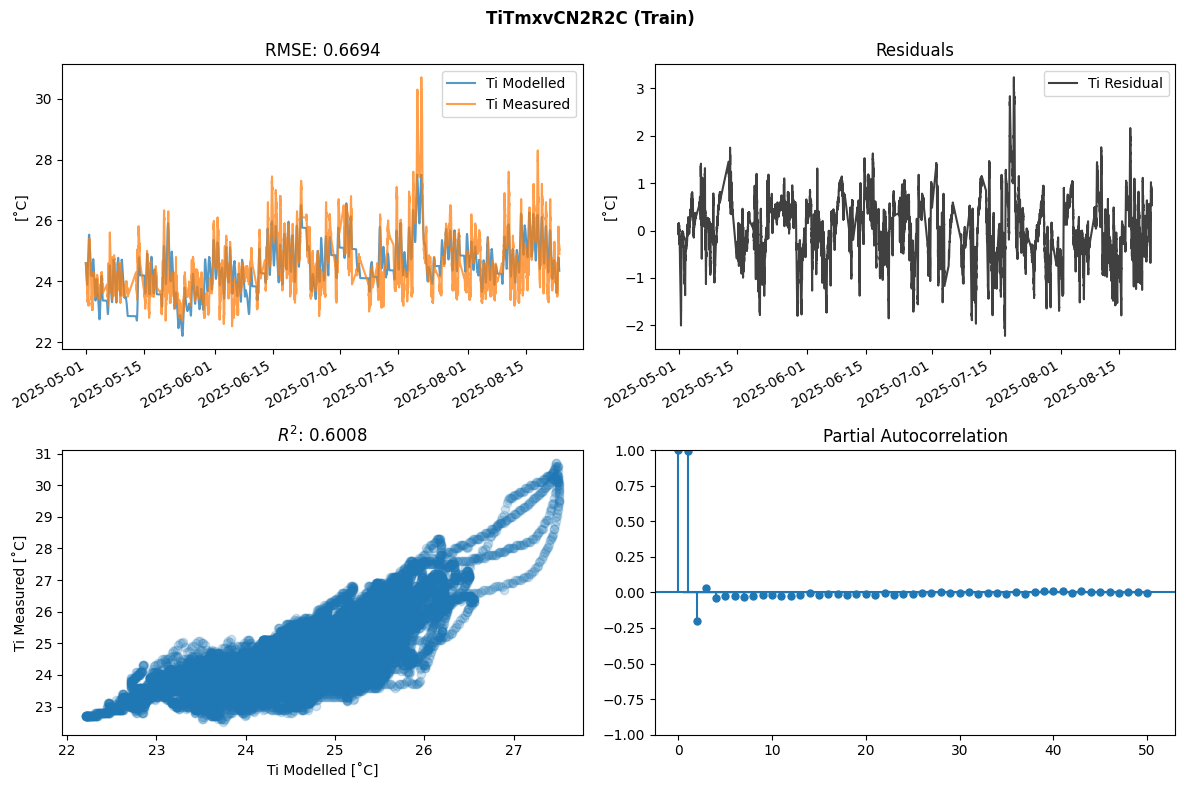

In [31]:
plot(y_train, train_results, 'TiTmxvCN2R2C (Train)')

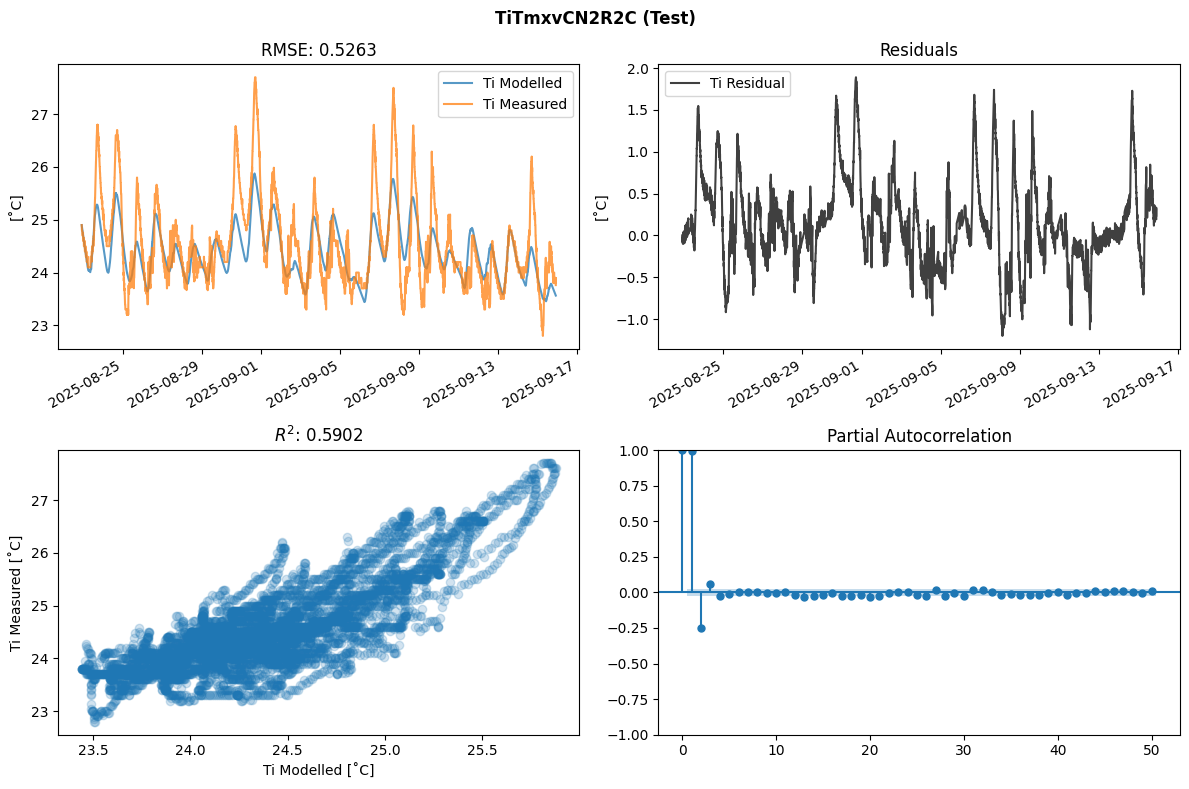

In [17]:
plot(y_test, test_results, 'TiTmxvCN2R2C (Test)')

In contrast, the `Ti` model has a poor fit on the training set (R2=0.79) which is clear from the temperature plots as well. Due to low model complexity there is a definite underfitting problem going in here, which of course also results in poor test set performance. This is hardly surprising, as the `Ti` model only keeps internal states of the internal temperatures (`Ti`) and it is unaware of the internal states of the heating system / building envelope temperatures  (`Th` and `Te` respectively) - both of which are important for describing the system components' thermal inertia.

## Using the Kalman Filter Model for Occupancy Estimation

The `TiTmxvCN2R2C_KF` model extends the base model with a Kalman filter that updates the occupancy estimate N at each timestep based on CO2 observations. This allows N to vary over time instead of staying constant.

In [29]:
# Reload the models module to get the new TiTmxvCN2R2C_KF class
importlib.reload(sys.modules['darkgreybox.models'])
from darkgreybox.models import TiTmxvCN2R2C_KF

# Add the CO2 observations to the input data for the Kalman filter
input_df['C_obs'] = input_df['C']  # Use measured CO2 as observations
input_df['P_N0'] = 1.0  # Initial variance of N estimate (constant for all rows)

# Update input_X to include C_obs and P_N0
input_X_kf = input_df[['Ta', 'Tfor', 'Q_vent', 'Q_solar', 'MVV', 'ACH', 'Ti0', 'Th0', 'xv0', 'C0', 'N0', 'C_obs', 'P_N0']]

# Split for KF model
X_train_kf, X_test_kf, _, _ = train_test_split(input_X_kf, input_y, test_size=0.2, shuffle=False)

# Add Kalman filter parameters to the training params
train_params_KF = train_params_TiTmxvCN2R2C.copy()
train_params_KF['Q_N'] = {'value': 0.5, 'vary': False}     # Process noise for N (persons²/h)
train_params_KF['R_C'] = {'value': 50.0, 'vary': False}    # Measurement noise for CO2 (ppm²)
train_params_KF['P_N0'] = {'value': 1.0, 'vary': False}    # Initial variance of N

print("Training parameters for Kalman Filter model:")
print(f"  Q_N (process noise): {train_params_KF['Q_N']['value']}")
print(f"  R_C (measurement noise): {train_params_KF['R_C']['value']}")

Training parameters for Kalman Filter model:
  Q_N (process noise): 0.5
  R_C (measurement noise): 50.0


In [30]:
# Create and fit the Kalman Filter model
models_kf = [TiTmxvCN2R2C_KF(train_params_KF, rec_duration)]

# Update ic_params_map for KF model
ic_params_map_kf = {
    'Ti0': lambda X_test, y_test, train_result: y_test.iloc[0],
    'Th0': lambda X_test, y_test, train_result: train_result.var['Th'][-1],
    'xv0': lambda X_test, y_test, train_result: X_test.iloc[0]['xv0'],
    'C0': lambda X_test, y_test, train_result: X_test.iloc[0]['C0'],
    'N0': lambda X_test, y_test, train_result: train_result.var['N'][-1],  # Use last estimated N
    'P_N0': lambda X_test, y_test, train_result: train_result.var['P_N'][-1],  # Use last variance
}

df_kf = darkgreyfit(
    models=models_kf,
    X_train=X_train_kf,
    y_train=y_train,
    X_test=X_test_kf,
    y_test=y_test,
    ic_params_map=ic_params_map_kf,
    error_metric=error_metric,
    prefit_filter=None,
    prefit_splits=None,
    n_jobs=1
)

print("Kalman Filter model training complete!")

2026-01-18 16:28:37,879 darkgreybox  INFO     Training models...
2026-01-18 16:31:30,650 darkgreybox  INFO     Generating predictions for 1 models...
Kalman Filter model training complete!


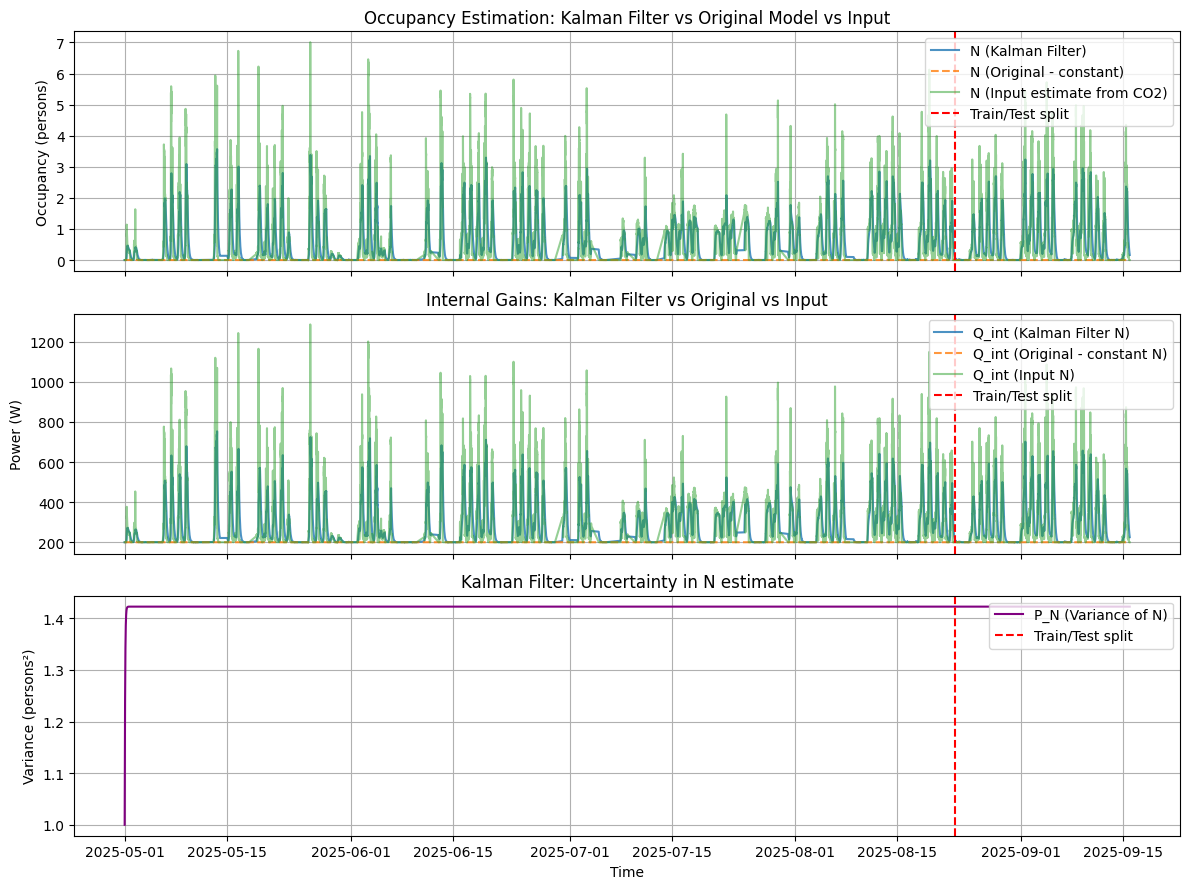


--- Model Comparison ---
Original Model - Train RMSE: 0.6694°C
Original Model - Test RMSE:  0.5648°C
Kalman Filter  - Train RMSE: 0.7193°C
Kalman Filter  - Test RMSE:  0.6548°C


In [32]:
# Extract results from Kalman Filter model
select_idx_kf = df_kf[('train', 'error')].argmin()
model_kf = df_kf.loc[select_idx_kf, ('train', 'model')]
train_results_kf = df_kf.loc[select_idx_kf, ('train', 'model_result')]
test_results_kf = df_kf.loc[select_idx_kf, ('test', 'model_result')]

# Extract N from original model (non-KF)
N_train = train_results.var['N']
N_test = test_results.var['N']

# Compare N from original model vs Kalman Filter model
N_kf_train = train_results_kf.var['N']
N_kf_test = test_results_kf.var['N']
N_kf_full = np.concatenate([N_kf_train, N_kf_test])

# Get parameters for Q_int calculation
q_pers = train_params_TiTmxvCN2R2C['q_pers']['value']
q_equip_var = train_params_TiTmxvCN2R2C['q_equip_var']['value']
Q_int_const = train_params_TiTmxvCN2R2C['Q_int_const']['value']

# Plot comparison of N estimates
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

idx = input_y.index

# Plot 1: N comparison
axes[0].plot(idx, N_kf_full, label='N (Kalman Filter)', alpha=0.8)
axes[0].plot(idx, np.concatenate([N_train, N_test]), label='N (Original - constant)', linestyle='--', alpha=0.8)
axes[0].plot(input_df.loc[idx, 'N'], label='N (Input estimate from CO2)', alpha=0.5)
axes[0].axvline(x=y_train.index[-1], color='r', linestyle='--', label='Train/Test split')
axes[0].set_ylabel('Occupancy (persons)')
axes[0].set_title('Occupancy Estimation: Kalman Filter vs Original Model vs Input')
axes[0].legend(loc='upper right')
axes[0].grid(True)

# Plot 2: Q_int comparison
Q_int_kf = Q_int_const + (q_pers + q_equip_var) * N_kf_full
Q_int_orig = Q_int_const + (q_pers + q_equip_var) * np.concatenate([N_train, N_test])
Q_int_input = Q_int_const + (q_pers + q_equip_var) * input_df.loc[idx, 'N'].values
axes[1].plot(idx, Q_int_kf, label='Q_int (Kalman Filter N)', alpha=0.8)
axes[1].plot(idx, Q_int_orig, label='Q_int (Original - constant N)', linestyle='--', alpha=0.8)
axes[1].plot(idx, Q_int_input, label='Q_int (Input N)', alpha=0.5)
axes[1].axvline(x=y_train.index[-1], color='r', linestyle='--', label='Train/Test split')
axes[1].set_ylabel('Power (W)')
axes[1].set_title('Internal Gains: Kalman Filter vs Original vs Input')
axes[1].legend(loc='upper right')
axes[1].grid(True)

# Plot 3: Variance of N (uncertainty)
P_N_train = train_results_kf.var['P_N']
P_N_test = test_results_kf.var['P_N']
P_N_full = np.concatenate([P_N_train, P_N_test])
axes[2].plot(idx, P_N_full, label='P_N (Variance of N)', color='purple')
axes[2].axvline(x=y_train.index[-1], color='r', linestyle='--', label='Train/Test split')
axes[2].set_ylabel('Variance (persons²)')
axes[2].set_xlabel('Time')
axes[2].set_title('Kalman Filter: Uncertainty in N estimate')
axes[2].legend(loc='upper right')
axes[2].grid(True)

plt.tight_layout()
plt.show()

# Print RMSE comparison
print(f"\n--- Model Comparison ---")
print(f"Original Model - Train RMSE: {df.loc[select_idx, ('train', 'error')]:.4f}°C")
print(f"Original Model - Test RMSE:  {df.loc[select_idx, ('test', 'error')]:.4f}°C")
print(f"Kalman Filter  - Train RMSE: {df_kf.loc[select_idx_kf, ('train', 'error')]:.4f}°C")
print(f"Kalman Filter  - Test RMSE:  {df_kf.loc[select_idx_kf, ('test', 'error')]:.4f}°C")

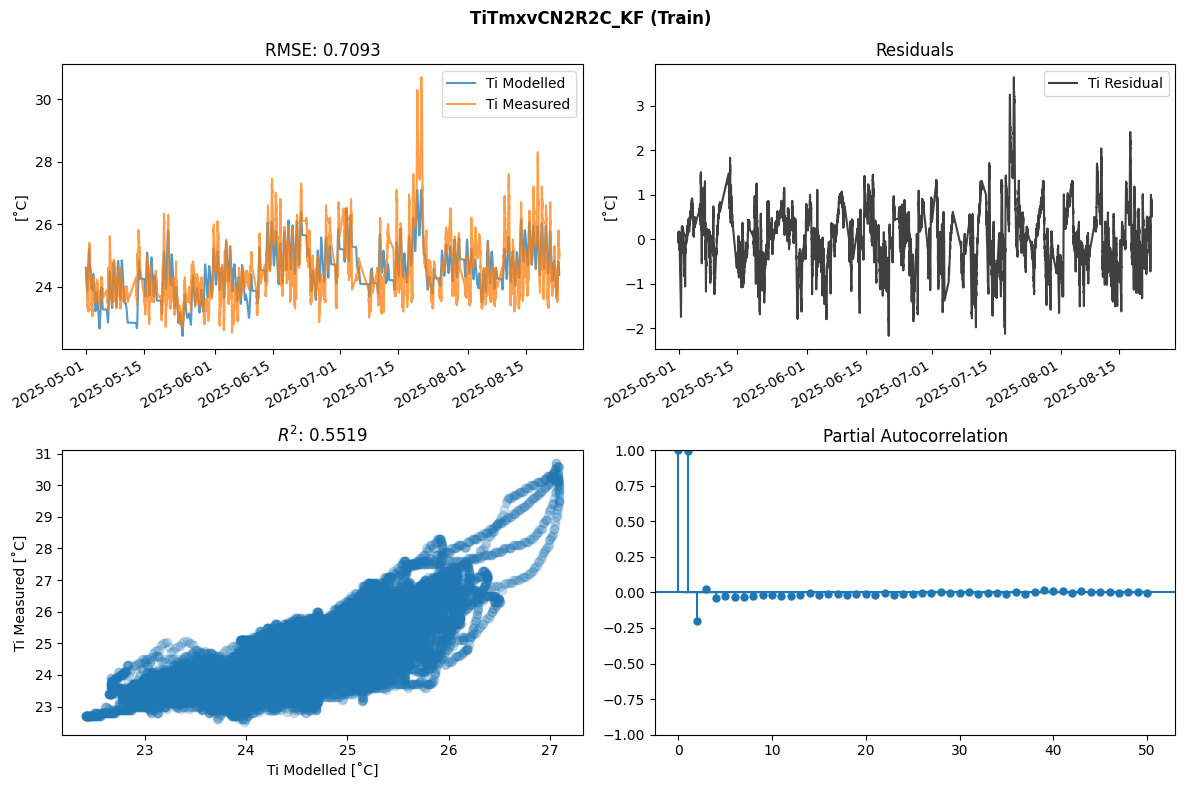

In [21]:
# Plot Train results for Kalman Filter model
plot(y_train, train_results_kf, 'TiTmxvCN2R2C_KF (Train)')

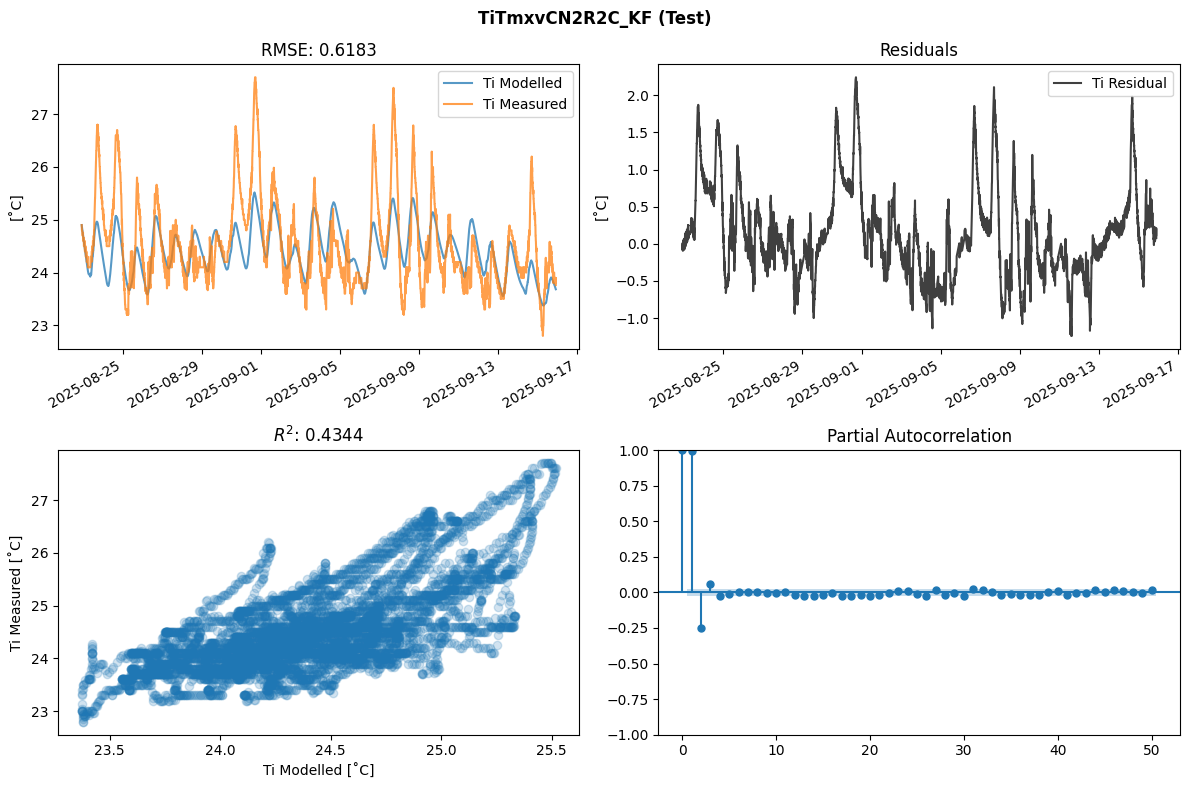

In [22]:
# Plot Test results for Kalman Filter model
plot(y_test, test_results_kf, 'TiTmxvCN2R2C_KF (Test)')

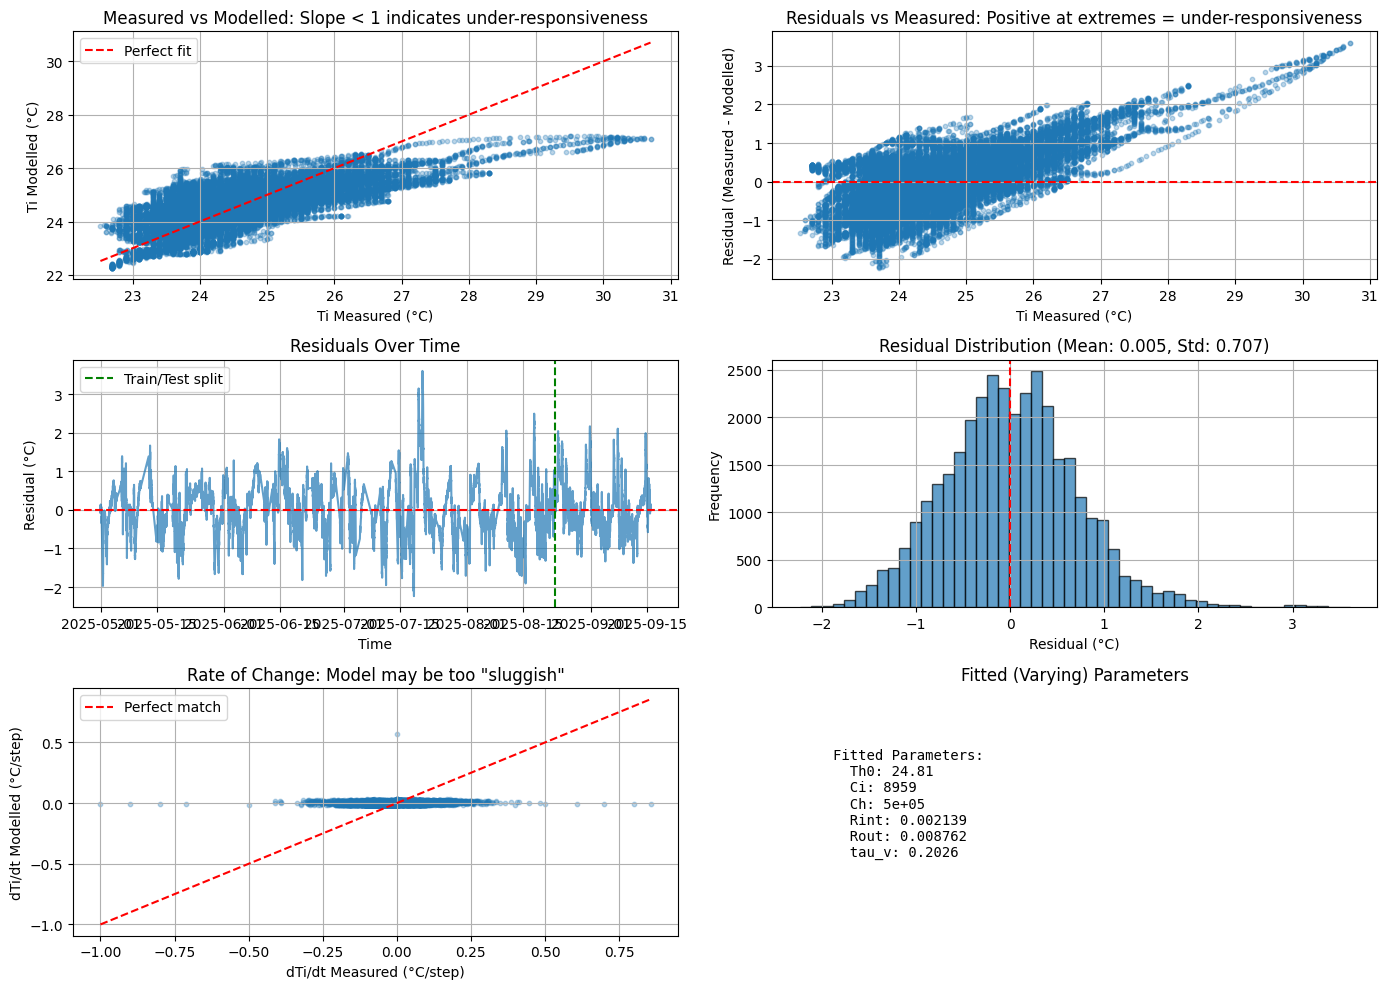


--- Under-responsiveness Analysis ---
Linear regression slope: 0.5234 (should be 1.0)
Intercept: 11.6910 (should be 0.0)
R²: 0.5166

Interpretation:
  → Slope < 1 means model is UNDER-RESPONSIVE (damped)
  → Model only captures 52.3% of the temperature variation

Likely causes:
  1. Ci (thermal capacitance) too HIGH → reduce max bound or initial value
  2. Missing time-varying heat sources (solar gains, occupancy)
  3. Resistances (Rint, Rout) not capturing actual heat transfer
  4. External disturbances not in model (window opening, infiltration)


In [33]:
# Diagnostic analysis: Why Ti_modelled doesn't reach extremes

# Combine train and test results (Z contains predicted values)
Ti_modelled = np.concatenate([train_results_kf.Z, test_results_kf.Z])
Ti_measured = np.concatenate([y_train.values, y_test.values])
idx = input_y.index

residuals = Ti_measured - Ti_modelled

fig, axes = plt.subplots(3, 2, figsize=(14, 10))

# Plot 1: Measured vs Modelled scatter plot
axes[0, 0].scatter(Ti_measured, Ti_modelled, alpha=0.3, s=10)
axes[0, 0].plot([Ti_measured.min(), Ti_measured.max()], 
                [Ti_measured.min(), Ti_measured.max()], 'r--', label='Perfect fit')
axes[0, 0].set_xlabel('Ti Measured (°C)')
axes[0, 0].set_ylabel('Ti Modelled (°C)')
axes[0, 0].set_title('Measured vs Modelled: Slope < 1 indicates under-responsiveness')
axes[0, 0].legend()
axes[0, 0].grid(True)

# Plot 2: Residuals vs Measured - should show pattern
axes[0, 1].scatter(Ti_measured, residuals, alpha=0.3, s=10)
axes[0, 1].axhline(y=0, color='r', linestyle='--')
axes[0, 1].set_xlabel('Ti Measured (°C)')
axes[0, 1].set_ylabel('Residual (Measured - Modelled)')
axes[0, 1].set_title('Residuals vs Measured: Positive at extremes = under-responsiveness')
axes[0, 1].grid(True)

# Plot 3: Residuals over time
axes[1, 0].plot(idx, residuals, alpha=0.7)
axes[1, 0].axhline(y=0, color='r', linestyle='--')
axes[1, 0].axvline(x=y_train.index[-1], color='g', linestyle='--', label='Train/Test split')
axes[1, 0].set_xlabel('Time')
axes[1, 0].set_ylabel('Residual (°C)')
axes[1, 0].set_title('Residuals Over Time')
axes[1, 0].legend()
axes[1, 0].grid(True)

# Plot 4: Histogram of residuals
axes[1, 1].hist(residuals, bins=50, edgecolor='black', alpha=0.7)
axes[1, 1].axvline(x=0, color='r', linestyle='--')
axes[1, 1].set_xlabel('Residual (°C)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title(f'Residual Distribution (Mean: {np.mean(residuals):.3f}, Std: {np.std(residuals):.3f})')
axes[1, 1].grid(True)

# Plot 5: Rate of change comparison
dTi_measured = np.diff(Ti_measured)
dTi_modelled = np.diff(Ti_modelled)
axes[2, 0].scatter(dTi_measured, dTi_modelled, alpha=0.3, s=10)
axes[2, 0].plot([dTi_measured.min(), dTi_measured.max()], 
                [dTi_measured.min(), dTi_measured.max()], 'r--', label='Perfect match')
axes[2, 0].set_xlabel('dTi/dt Measured (°C/step)')
axes[2, 0].set_ylabel('dTi/dt Modelled (°C/step)')
axes[2, 0].set_title('Rate of Change: Model may be too "sluggish"')
axes[2, 0].legend()
axes[2, 0].grid(True)

# Plot 6: Show fitted parameters
param_text = "Fitted Parameters:\n"
for name, param in model_kf.result.params.items():
    if param.vary:
        param_text += f"  {name}: {param.value:.4g}\n"
axes[2, 1].text(0.1, 0.5, param_text, transform=axes[2, 1].transAxes, 
                fontsize=10, verticalalignment='center', fontfamily='monospace')
axes[2, 1].axis('off')
axes[2, 1].set_title('Fitted (Varying) Parameters')

plt.tight_layout()
plt.show()

# Quantify the under-responsiveness
from scipy import stats
slope, intercept, r_value, p_value, std_err = stats.linregress(Ti_measured, Ti_modelled)
print(f"\n--- Under-responsiveness Analysis ---")
print(f"Linear regression slope: {slope:.4f} (should be 1.0)")
print(f"Intercept: {intercept:.4f} (should be 0.0)")
print(f"R²: {r_value**2:.4f}")
print(f"\nInterpretation:")
if slope < 0.95:
    print(f"  → Slope < 1 means model is UNDER-RESPONSIVE (damped)")
    print(f"  → Model only captures {slope*100:.1f}% of the temperature variation")
    print(f"\nLikely causes:")
    print(f"  1. Ci (thermal capacitance) too HIGH → reduce max bound or initial value")
    print(f"  2. Missing time-varying heat sources (solar gains, occupancy)")
    print(f"  3. Resistances (Rint, Rout) not capturing actual heat transfer")
    print(f"  4. External disturbances not in model (window opening, infiltration)")
else:
    print(f"  → Slope ≈ 1 means model responsiveness is good")

## Model Structure Analysis & Residual Diagnostics

Let's analyze:
1. **Model equations** for potential structural issues
2. **Residual correlations** with inputs to identify missing effects

In [34]:
# ============================================================================
# MODEL STRUCTURE ANALYSIS
# ============================================================================
print("=" * 70)
print("MODEL STRUCTURE ANALYSIS - TiTmxvCN2R2C")
print("=" * 70)

# Get fitted parameters
fitted_params = model_kf.result.params

print("\n### Model Equations (from source code):")
print("""
Temperature dynamics (2R2C model):
    dTi/dt = (Th - Ti)/(Rint·Ci) + (Ta - Ti)/(Rout·Ci) + (Q_vent + Q_solar + Q_int)/Ci
    dTh/dt = (Ti - Th)/(Rint·Ch) + Q_heat/Ch

Where:
    Q_heat = alpha · xv · (Tfor - Th)  [Radiator heat]
    Q_int  = Q_int_const + (q_pers + q_equip_var) · N  [Internal gains]
    dxv/dt = (MVV/100 - xv) / tau_v  [Valve dynamics]
""")

# Calculate time constants
Ci = fitted_params['Ci'].value
Ch = fitted_params['Ch'].value
Rint = fitted_params['Rint'].value
Rout = fitted_params['Rout'].value

tau_i_int = Rint * Ci / 3600  # Time constant Ti-Th (hours)
tau_i_out = Rout * Ci / 3600  # Time constant Ti-Ta (hours)
tau_h = Rint * Ch / 3600      # Time constant Th (hours)

print("\n### Fitted Parameters and Time Constants:")
print(f"  Ci (room capacitance):     {Ci:.0f} J/K")
print(f"  Ch (thermal mass):         {Ch:.0f} J/K")
print(f"  Rint (internal resistance): {Rint:.4f} K/W")
print(f"  Rout (external resistance): {Rout:.4f} K/W")
print(f"\n  τ_i_int = Rint·Ci/3600 = {tau_i_int:.2f} hours (Ti response to Th)")
print(f"  τ_i_out = Rout·Ci/3600 = {tau_i_out:.2f} hours (Ti response to Ta)")
print(f"  τ_h = Rint·Ch/3600     = {tau_h:.2f} hours (Th response)")

print("\n### Potential Structural Issues:")
issues = []

# Check if Ch is at boundary
if Ch >= 0.95 * train_params_TiTmxvCN2R2C['Ch']['max']:
    issues.append(f"⚠️ Ch at upper bound ({Ch:.0f} ≈ max={train_params_TiTmxvCN2R2C['Ch']['max']})")
    issues.append("   → Model wants MORE damping than allowed")
    issues.append("   → Likely compensating for unmodeled disturbances")

# Check if time constants are very large
if tau_h > 100:
    issues.append(f"⚠️ τ_h = {tau_h:.1f} hours is VERY LARGE")
    issues.append("   → Thermal mass responds too slowly")
    issues.append("   → Reduces model's ability to track rapid changes")

# Check heat transfer coefficients
UA_int = 1/Rint  # W/K (between Ti and Th)
UA_out = 1/Rout  # W/K (between Ti and Ta)

print(f"\n  UA_int (Ti↔Th) = 1/Rint = {UA_int:.1f} W/K")
print(f"  UA_out (Ti↔Ta) = 1/Rout = {UA_out:.1f} W/K")

if UA_int > UA_out * 10:
    issues.append(f"⚠️ UA_int >> UA_out ({UA_int:.0f} vs {UA_out:.0f})")
    issues.append("   → Strong coupling to thermal mass, weak to ambient")
    issues.append("   → Ti largely follows Th, less responsive to Ta")

# Check dTi/dt sensitivity
dt = rec_duration  # hours
example_dT = 5  # Example temperature difference

# Maximum possible dTi/dt from each term
max_dTi_from_Th = example_dT / (Rint * Ci) * dt * 3600
max_dTi_from_Ta = example_dT / (Rout * Ci) * dt * 3600
max_dTi_from_Q = 500 / Ci * dt * 3600  # 500W example

print(f"\n### Sensitivity Analysis (per timestep, dt={dt:.4f}h):")
print(f"  Max ΔTi from (Th-Ti)=5°C: {max_dTi_from_Th:.4f} °C/step")
print(f"  Max ΔTi from (Ta-Ti)=5°C: {max_dTi_from_Ta:.4f} °C/step")
print(f"  Max ΔTi from Q=500W:      {max_dTi_from_Q:.4f} °C/step")

if max_dTi_from_Th < 0.01 and max_dTi_from_Ta < 0.01:
    issues.append(f"⚠️ Temperature sensitivities are VERY LOW")
    issues.append("   → Model can barely change Ti per timestep")
    issues.append("   → This causes the sluggish/damped behavior")

if issues:
    print("\n### 🚨 ISSUES FOUND:")
    for issue in issues:
        print(f"  {issue}")
else:
    print("\n### ✅ No obvious structural issues found")

MODEL STRUCTURE ANALYSIS - TiTmxvCN2R2C

### Model Equations (from source code):

Temperature dynamics (2R2C model):
    dTi/dt = (Th - Ti)/(Rint·Ci) + (Ta - Ti)/(Rout·Ci) + (Q_vent + Q_solar + Q_int)/Ci
    dTh/dt = (Ti - Th)/(Rint·Ch) + Q_heat/Ch

Where:
    Q_heat = alpha · xv · (Tfor - Th)  [Radiator heat]
    Q_int  = Q_int_const + (q_pers + q_equip_var) · N  [Internal gains]
    dxv/dt = (MVV/100 - xv) / tau_v  [Valve dynamics]


### Fitted Parameters and Time Constants:
  Ci (room capacitance):     8959 J/K
  Ch (thermal mass):         500000 J/K
  Rint (internal resistance): 0.0021 K/W
  Rout (external resistance): 0.0088 K/W

  τ_i_int = Rint·Ci/3600 = 0.01 hours (Ti response to Th)
  τ_i_out = Rout·Ci/3600 = 0.02 hours (Ti response to Ta)
  τ_h = Rint·Ch/3600     = 0.30 hours (Th response)

### Potential Structural Issues:

  UA_int (Ti↔Th) = 1/Rint = 467.6 W/K
  UA_out (Ti↔Ta) = 1/Rout = 114.1 W/K

### Sensitivity Analysis (per timestep, dt=0.0833h):
  Max ΔTi from (Th-Ti)=5


RESIDUAL CORRELATION ANALYSIS - Identifying Missing Effects

### Correlation of Residuals with Inputs:
(Significant correlations indicate model is missing these effects)



C:\Users\clemr\AppData\Local\Temp\ipykernel_14968\55768140.py:44: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p_value = stats.pearsonr(values[mask], residuals[mask])
C:\Users\clemr\AppData\Local\Temp\ipykernel_14968\55768140.py:74: RankWarning: Polyfit may be poorly conditioned
  z = np.polyfit(values[mask], residuals[mask], 1)


Input Variable             Correlation      p-value    Significance
----------------------------------------------------------------------
ACH                            -0.4525     0.00e+00   *** ← STRONG
Q_vent                          0.3856     0.00e+00   *** ← STRONG
N (Occupancy)                  -0.1950    3.27e-293   *** ← Moderate
svent (Vent Status)                nan          nan       
Ti_measured                     0.6854     0.00e+00   *** ← STRONG
C (CO2)                        -0.1883    2.92e-273   *** ← Moderate
Hour of day                     0.1782    1.57e-244   *** ← Moderate
Gk (Solar Irr.)                -0.1779    1.60e-243   *** ← Moderate
Q_solar                        -0.1779    1.60e-243   *** ← Moderate
Tfor (Supply)                   0.1463    1.73e-164   *** 
Ta (Ambient)                   -0.1064     1.81e-87   *** 
MVV (Valve)                     0.0144     7.56e-03    ** 
|dTi/dt|_measured              -0.0081     1.31e-01       


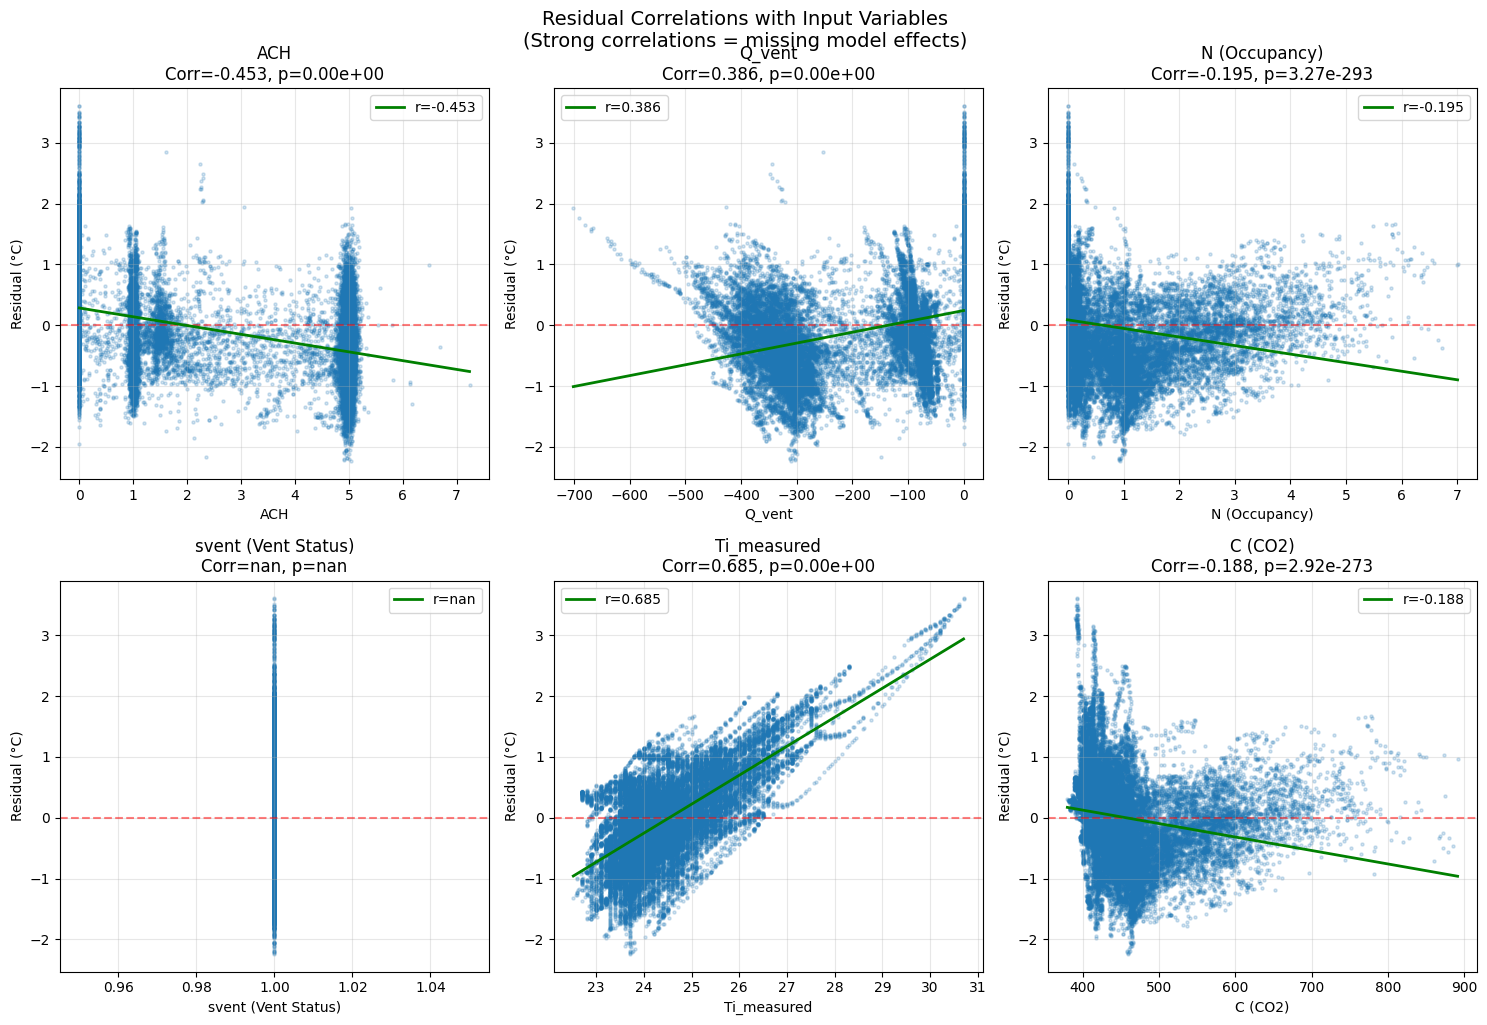

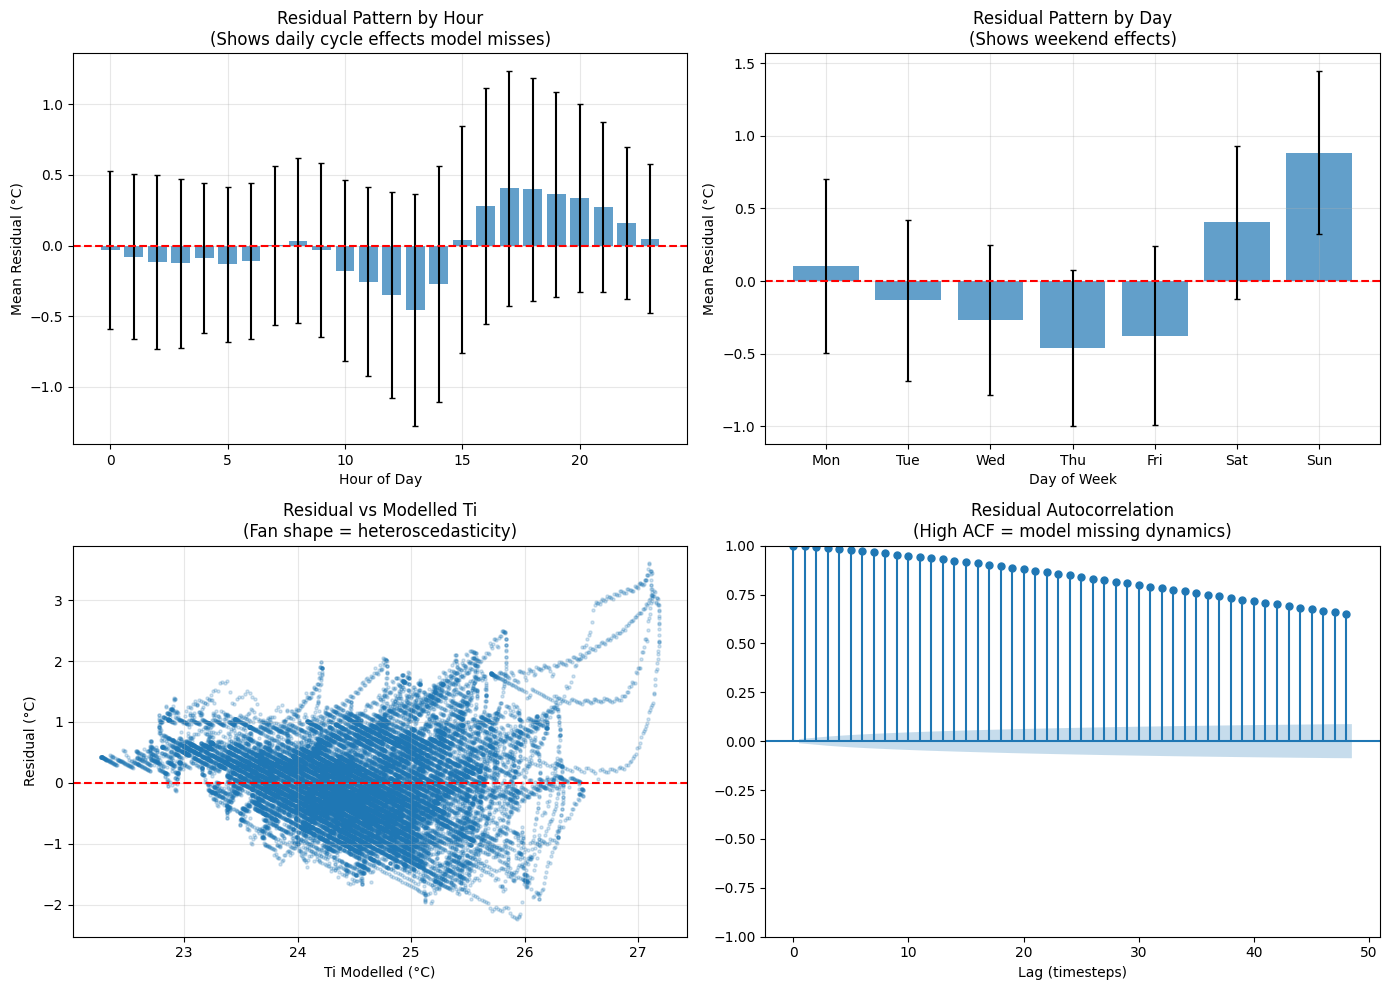


DIAGNOSIS SUMMARY

### Key Findings:

1. MISSING EFFECTS (strong residual correlations):
   • ACH: r=-0.453
   • Q_vent: r=0.386
     → Ventilation effects may be underestimated
   • N (Occupancy): r=-0.195
   • Ti_measured: r=0.685
     → When Ti_measured is HIGH, residual is POSITIVE (model underestimates)
     → When Ti_measured is LOW, residual is NEGATIVE (model overestimates)
     → This IS the under-responsiveness problem
   • C (CO2): r=-0.188
   • Hour of day: r=0.178
     → Missing time-of-day effects (schedules, occupancy patterns)
   • Gk (Solar Irr.): r=-0.178
     → Solar gains may not be properly captured
   • Q_solar: r=-0.178
     → Solar gains may not be properly captured

2. RECOMMENDED ACTIONS:
   • Reduce Ci/Ch further to allow faster response
   • Check if Q_solar scaling (g * A_w) is correct
   • Consider adding time-varying internal gains schedules
   • Check ventilation model (Q_vent calculation)


In [35]:
# ============================================================================
# RESIDUAL CORRELATION ANALYSIS - What's the model missing?
# ============================================================================
from scipy import stats

print("\n" + "=" * 70)
print("RESIDUAL CORRELATION ANALYSIS - Identifying Missing Effects")
print("=" * 70)

# Calculate residuals
Ti_modelled = np.concatenate([train_results_kf.Z, test_results_kf.Z])
Ti_measured = np.concatenate([y_train.values, y_test.values])
residuals = Ti_measured - Ti_modelled
idx = input_y.index

# Get all input variables aligned with residuals
inputs_to_check = {
    'Ta (Ambient)': input_df.loc[idx, 'Ta'].values,
    'Tfor (Supply)': input_df.loc[idx, 'Tfor'].values,
    'Q_vent': input_df.loc[idx, 'Q_vent'].values,
    'Q_solar': input_df.loc[idx, 'Q_solar'].values,
    'MVV (Valve)': input_df.loc[idx, 'MVV'].values,
    'ACH': input_df.loc[idx, 'ACH'].values,
    'N (Occupancy)': input_df.loc[idx, 'N'].values,
    'Gk (Solar Irr.)': input_df.loc[idx, 'Gk'].values,
    'C (CO2)': input_df.loc[idx, 'C'].values,
    'svent (Vent Status)': input_df.loc[idx, 'svent'].values,
}

# Also add derived variables
inputs_to_check['Ti_measured'] = Ti_measured
inputs_to_check['|dTi/dt|_measured'] = np.abs(np.gradient(Ti_measured))
inputs_to_check['Hour of day'] = np.array([t.hour for t in idx])

# Calculate correlations
print("\n### Correlation of Residuals with Inputs:")
print("(Significant correlations indicate model is missing these effects)\n")

correlations = []
for name, values in inputs_to_check.items():
    # Handle NaN
    mask = ~(np.isnan(values) | np.isnan(residuals))
    if mask.sum() > 10:
        corr, p_value = stats.pearsonr(values[mask], residuals[mask])
        correlations.append((name, corr, p_value))

# Sort by absolute correlation
correlations.sort(key=lambda x: abs(x[1]), reverse=True)

print(f"{'Input Variable':<25} {'Correlation':>12} {'p-value':>12} {'Significance':>15}")
print("-" * 70)
for name, corr, p_val in correlations:
    sig = "***" if p_val < 0.001 else ("**" if p_val < 0.01 else ("*" if p_val < 0.05 else ""))
    interpretation = ""
    if abs(corr) > 0.3:
        interpretation = "← STRONG"
    elif abs(corr) > 0.15:
        interpretation = "← Moderate"
    print(f"{name:<25} {corr:>12.4f} {p_val:>12.2e} {sig:>5} {interpretation}")

# Visualize top correlations
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

# Plot top 6 correlations
for i, (name, corr, p_val) in enumerate(correlations[:6]):
    values = inputs_to_check[name]
    mask = ~(np.isnan(values) | np.isnan(residuals))
    
    axes[i].scatter(values[mask], residuals[mask], alpha=0.2, s=5)
    axes[i].axhline(y=0, color='r', linestyle='--', alpha=0.5)
    
    # Add regression line
    z = np.polyfit(values[mask], residuals[mask], 1)
    p = np.poly1d(z)
    x_line = np.linspace(np.nanmin(values), np.nanmax(values), 100)
    axes[i].plot(x_line, p(x_line), 'g-', linewidth=2, label=f'r={corr:.3f}')
    
    axes[i].set_xlabel(name)
    axes[i].set_ylabel('Residual (°C)')
    axes[i].set_title(f'{name}\nCorr={corr:.3f}, p={p_val:.2e}')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle('Residual Correlations with Input Variables\n(Strong correlations = missing model effects)', 
             y=1.02, fontsize=14)
plt.show()

# Time-based analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Hour of day pattern
hours = np.array([t.hour for t in idx])
hourly_mean = [np.mean(residuals[hours == h]) for h in range(24)]
hourly_std = [np.std(residuals[hours == h]) for h in range(24)]
axes[0, 0].bar(range(24), hourly_mean, yerr=hourly_std, capsize=2, alpha=0.7)
axes[0, 0].axhline(y=0, color='r', linestyle='--')
axes[0, 0].set_xlabel('Hour of Day')
axes[0, 0].set_ylabel('Mean Residual (°C)')
axes[0, 0].set_title('Residual Pattern by Hour\n(Shows daily cycle effects model misses)')
axes[0, 0].grid(True, alpha=0.3)

# Day of week pattern
days = np.array([t.dayofweek for t in idx])
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
daily_mean = [np.mean(residuals[days == d]) for d in range(7)]
daily_std = [np.std(residuals[days == d]) for d in range(7)]
axes[0, 1].bar(range(7), daily_mean, yerr=daily_std, capsize=2, alpha=0.7)
axes[0, 1].axhline(y=0, color='r', linestyle='--')
axes[0, 1].set_xticks(range(7))
axes[0, 1].set_xticklabels(day_names)
axes[0, 1].set_xlabel('Day of Week')
axes[0, 1].set_ylabel('Mean Residual (°C)')
axes[0, 1].set_title('Residual Pattern by Day\n(Shows weekend effects)')
axes[0, 1].grid(True, alpha=0.3)

# Residual vs modeled temperature (heteroscedasticity)
axes[1, 0].scatter(Ti_modelled, residuals, alpha=0.2, s=5)
axes[1, 0].axhline(y=0, color='r', linestyle='--')
axes[1, 0].set_xlabel('Ti Modelled (°C)')
axes[1, 0].set_ylabel('Residual (°C)')
axes[1, 0].set_title('Residual vs Modelled Ti\n(Fan shape = heteroscedasticity)')
axes[1, 0].grid(True, alpha=0.3)

# Lagged residual autocorrelation
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(residuals, lags=48, ax=axes[1, 1], alpha=0.05)
axes[1, 1].set_xlabel('Lag (timesteps)')
axes[1, 1].set_title('Residual Autocorrelation\n(High ACF = model missing dynamics)')

plt.tight_layout()
plt.show()

# Summary
print("\n" + "=" * 70)
print("DIAGNOSIS SUMMARY")
print("=" * 70)

print("\n### Key Findings:")

# Find strongest correlations
strong_corrs = [(n, c) for n, c, p in correlations if abs(c) > 0.15]
if strong_corrs:
    print("\n1. MISSING EFFECTS (strong residual correlations):")
    for name, corr in strong_corrs:
        direction = "↑" if corr > 0 else "↓"
        print(f"   • {name}: r={corr:.3f}")
        if 'Ti' in name or 'measured' in name.lower():
            print(f"     → When Ti_measured is HIGH, residual is POSITIVE (model underestimates)")
            print(f"     → When Ti_measured is LOW, residual is NEGATIVE (model overestimates)")
            print(f"     → This IS the under-responsiveness problem")
        elif 'solar' in name.lower() or 'Gk' in name:
            print(f"     → Solar gains may not be properly captured")
        elif 'vent' in name.lower():
            print(f"     → Ventilation effects may be underestimated")
        elif 'Hour' in name:
            print(f"     → Missing time-of-day effects (schedules, occupancy patterns)")

print("\n2. RECOMMENDED ACTIONS:")
print("   • Reduce Ci/Ch further to allow faster response")
print("   • Check if Q_solar scaling (g * A_w) is correct")
print("   • Consider adding time-varying internal gains schedules")
print("   • Check ventilation model (Q_vent calculation)")

## Q_vent Investigation and Fix

The strong correlation between residuals and Q_vent/ACH suggests the ventilation model has issues. Let's investigate.

Q_VENT INVESTIGATION

### Current Q_vent Statistics:
  Min:  -701.3 W
  Max:  -0.0 W
  Mean: -132.6 W
  Std:  152.8 W

### Distribution of Q_vent values:
  Negative (cooling): 18965 (54.9%)
  Zero:               15586 (45.1%)
  Positive (heating): 0 (0.0%)

### Key Input Variables:
  Ti range: 22.5°C to 30.7°C (mean: 24.5°C)

### The Problem:
  When Ti = 24.5°C (mean), (20 - Ti) = -4.5
  Since Ti is mostly > 20°C, Q_vent is mostly NEGATIVE
  This means ventilation is treated as COOLING the room

### Model Equation Analysis:
  In the model: dTi/dt = ... + (Q_vent + Q_solar + Q_int) / Ci
  When Q_vent < 0: This REDUCES Ti (cooling)
  This is CORRECT physics if ventilation air is cooler than room air!

### BUT: What temperature is the ventilation air?
  Ta (outdoor) range: 4.6°C to 28.3°C (mean: 16.4°C)
  If ventilation air = Ta, then Q_vent formula should use (Ta - Ti), not (20 - Ti)!

### Comparison of Q_vent calculations:
  Current (using 20°C):    Mean = -132.6 W
  With outdoor air (T

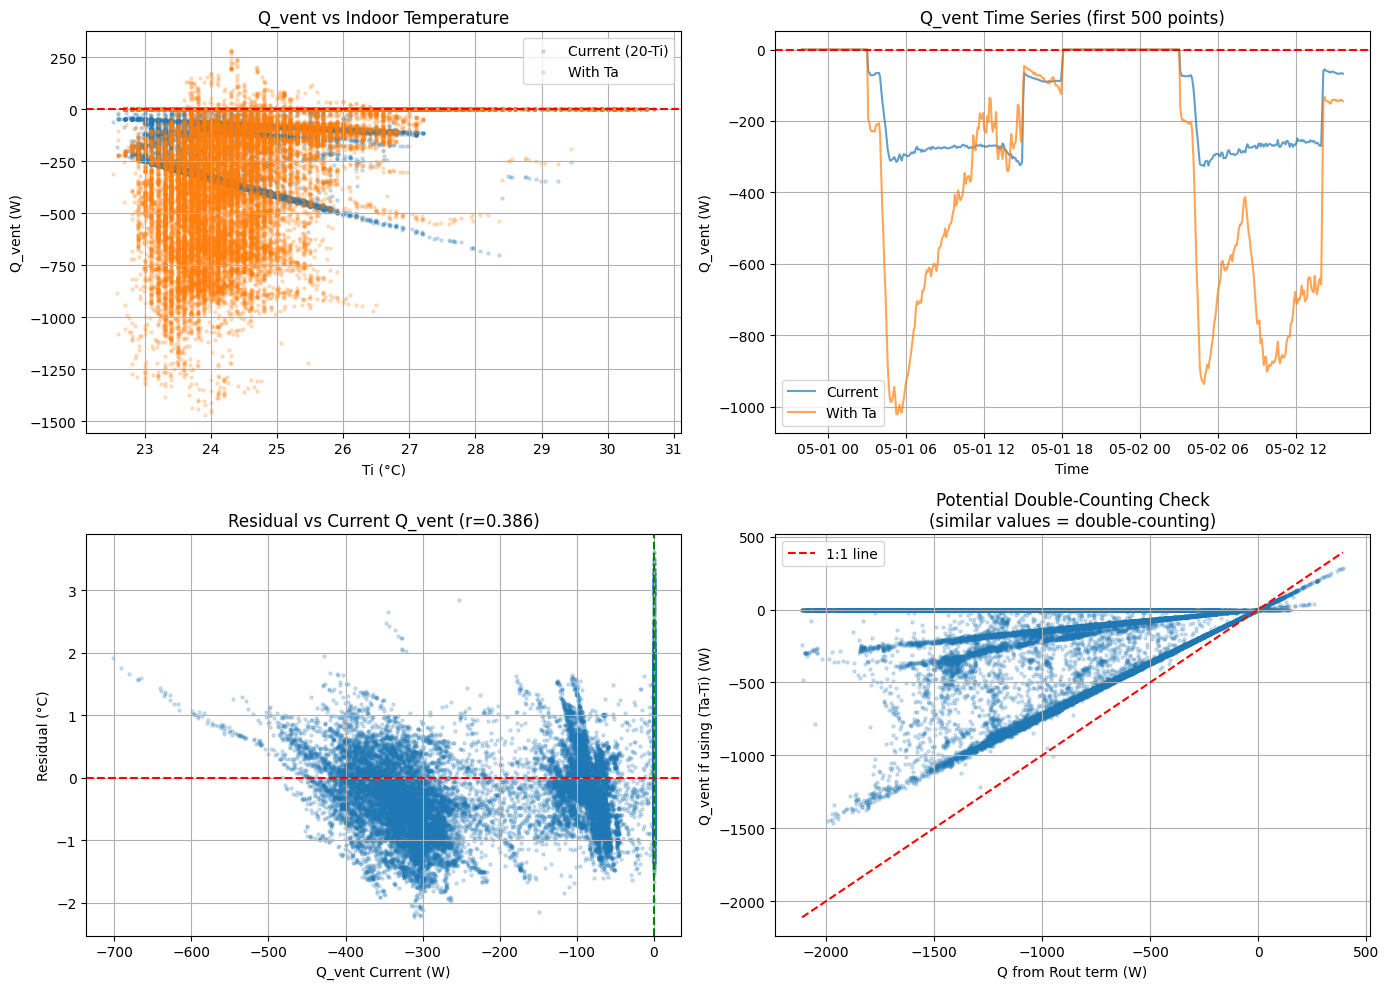


### Double-Counting Analysis:
  UA_out (from Rout) = 114.1 W/K
  Ventilation UA = rho*cp*Q/3600 = 32.2 W/K (at mean Q)

  If these are similar, ventilation is already captured by Rout!


In [36]:
# ============================================================================
# Q_VENT INVESTIGATION
# ============================================================================
print("=" * 70)
print("Q_VENT INVESTIGATION")
print("=" * 70)

# Current Q_vent calculation:
# Q_vent = svent * 1.2 * 1000 * Q * (20 - Ti) / 3600
# Where:
#   svent = ventilation status (0 or 1)
#   1.2 = air density (kg/m³)
#   1000 = specific heat of air (J/kg·K)
#   Q = airflow rate (m³/h from FCI01)
#   (20 - Ti) = temperature difference (setpoint - indoor)
#   /3600 = convert from J/h to W

idx = input_y.index

print("\n### Current Q_vent Statistics:")
Q_vent = input_df.loc[idx, 'Q_vent']
print(f"  Min:  {Q_vent.min():.1f} W")
print(f"  Max:  {Q_vent.max():.1f} W")
print(f"  Mean: {Q_vent.mean():.1f} W")
print(f"  Std:  {Q_vent.std():.1f} W")

print("\n### Distribution of Q_vent values:")
print(f"  Negative (cooling): {(Q_vent < 0).sum()} ({100*(Q_vent < 0).mean():.1f}%)")
print(f"  Zero:               {(Q_vent == 0).sum()} ({100*(Q_vent == 0).mean():.1f}%)")
print(f"  Positive (heating): {(Q_vent > 0).sum()} ({100*(Q_vent > 0).mean():.1f}%)")

print("\n### Key Input Variables:")
Ti = input_df.loc[idx, 'Ti']
print(f"  Ti range: {Ti.min():.1f}°C to {Ti.max():.1f}°C (mean: {Ti.mean():.1f}°C)")

# The issue: When Ti > 20°C, Q_vent is NEGATIVE (model treats as cooling)
# But the model equation adds Q_vent to Ti:
#   dTi/dt = ... + Q_vent / Ci
# So negative Q_vent → Ti decreases (cooling effect)

print("\n### The Problem:")
print(f"  When Ti = {Ti.mean():.1f}°C (mean), (20 - Ti) = {20 - Ti.mean():.1f}")
print(f"  Since Ti is mostly > 20°C, Q_vent is mostly NEGATIVE")
print(f"  This means ventilation is treated as COOLING the room")

# Check model equation usage
print("\n### Model Equation Analysis:")
print("  In the model: dTi/dt = ... + (Q_vent + Q_solar + Q_int) / Ci")
print("  When Q_vent < 0: This REDUCES Ti (cooling)")
print("  This is CORRECT physics if ventilation air is cooler than room air!")

# But let's check if the ventilation is actually bringing in outdoor air
Ta = input_df.loc[idx, 'Ta']
print(f"\n### BUT: What temperature is the ventilation air?")
print(f"  Ta (outdoor) range: {Ta.min():.1f}°C to {Ta.max():.1f}°C (mean: {Ta.mean():.1f}°C)")
print(f"  If ventilation air = Ta, then Q_vent formula should use (Ta - Ti), not (20 - Ti)!")

# Calculate what Q_vent SHOULD be if using outdoor air
Q_flow = input_df.loc[idx, 'Q']  # m³/h
svent = input_df.loc[idx, 'svent']
rho_cp = 1.2 * 1000  # kg/m³ * J/kg·K = J/m³·K

# Current formula: assumes setpoint at 20°C
Q_vent_current = svent * rho_cp * Q_flow * (20 - Ti) / 3600  # W

# Correct formula: should use actual supply air temperature
# For mechanical ventilation, supply air is often pre-heated/cooled
# For natural ventilation, it's outdoor air temperature
Q_vent_with_Ta = svent * rho_cp * Q_flow * (Ta - Ti) / 3600  # W

print("\n### Comparison of Q_vent calculations:")
print(f"  Current (using 20°C):    Mean = {Q_vent_current.mean():.1f} W")
print(f"  With outdoor air (Ta):   Mean = {Q_vent_with_Ta.mean():.1f} W")

# The correlation issue: 
print("\n" + "=" * 70)
print("DIAGNOSIS: POTENTIAL DOUBLE-COUNTING OR WRONG REFERENCE")
print("=" * 70)

print("""
The issue is that Q_vent uses a FIXED reference temperature (20°C) instead of
the actual supply air temperature. This creates problems:

1. When Ti > 20°C: Q_vent < 0 (appears as cooling)
   But the model ALSO has (Ta - Ti)/Rout term which handles outdoor losses!
   
2. The correlation analysis shows:
   - ACH has r = -0.45 with residuals
   - Q_vent has r = +0.39 with residuals
   
   These have OPPOSITE signs, suggesting the ventilation effect is being
   modeled incorrectly or double-counted.

POSSIBLE FIXES:
A) Set Q_vent = 0 and let the model handle ventilation via (Ta-Ti)/Rout term
B) Use Q_vent with actual supply air temperature: Q_vent = rho*cp*Q*(T_supply - Ti)
C) The current Rout already includes ventilation UA, so Q_vent is double-counting
""")

# Visualize the difference
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Q_vent vs Ti
axes[0, 0].scatter(Ti, Q_vent_current, alpha=0.2, s=5, label='Current (20-Ti)')
axes[0, 0].scatter(Ti, Q_vent_with_Ta, alpha=0.2, s=5, label='With Ta')
axes[0, 0].axhline(y=0, color='r', linestyle='--')
axes[0, 0].set_xlabel('Ti (°C)')
axes[0, 0].set_ylabel('Q_vent (W)')
axes[0, 0].set_title('Q_vent vs Indoor Temperature')
axes[0, 0].legend()
axes[0, 0].grid(True)

# Plot 2: Time series comparison
sample_idx = idx[:min(500, len(idx))]
axes[0, 1].plot(sample_idx, Q_vent_current.loc[sample_idx], label='Current', alpha=0.7)
axes[0, 1].plot(sample_idx, Q_vent_with_Ta.loc[sample_idx], label='With Ta', alpha=0.7)
axes[0, 1].axhline(y=0, color='r', linestyle='--')
axes[0, 1].set_xlabel('Time')
axes[0, 1].set_ylabel('Q_vent (W)')
axes[0, 1].set_title('Q_vent Time Series (first 500 points)')
axes[0, 1].legend()
axes[0, 1].grid(True)

# Plot 3: Residual vs Q_vent comparison
axes[1, 0].scatter(Q_vent_current, residuals, alpha=0.2, s=5)
axes[1, 0].axhline(y=0, color='r', linestyle='--')
axes[1, 0].axvline(x=0, color='g', linestyle='--')
axes[1, 0].set_xlabel('Q_vent Current (W)')
axes[1, 0].set_ylabel('Residual (°C)')
axes[1, 0].set_title(f'Residual vs Current Q_vent (r={stats.pearsonr(Q_vent_current, residuals)[0]:.3f})')
axes[1, 0].grid(True)

# Plot 4: Check if Rout already handles ventilation
# Calculate the heat loss through Rout
UA_out = 1 / Rout  # W/K
Q_loss_Rout = UA_out * (Ta - Ti)  # W (heat flow from ambient)

# Compare with ventilation heat
Q_vent_UA = rho_cp * Q_flow / 3600 * (Ta - Ti)  # Ventilation UA term (W)

axes[1, 1].scatter(Q_loss_Rout, Q_vent_UA, alpha=0.2, s=5)
axes[1, 1].plot([Q_loss_Rout.min(), Q_loss_Rout.max()], 
                [Q_loss_Rout.min(), Q_loss_Rout.max()], 'r--', label='1:1 line')
axes[1, 1].set_xlabel('Q from Rout term (W)')
axes[1, 1].set_ylabel('Q_vent if using (Ta-Ti) (W)')
axes[1, 1].set_title('Potential Double-Counting Check\n(similar values = double-counting)')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

# Calculate potential double-counting magnitude
print("\n### Double-Counting Analysis:")
print(f"  UA_out (from Rout) = {UA_out:.1f} W/K")
print(f"  Ventilation UA = rho*cp*Q/3600 = {(rho_cp * Q_flow.mean() / 3600):.1f} W/K (at mean Q)")
print(f"\n  If these are similar, ventilation is already captured by Rout!")

In [37]:
# ============================================================================
# FIX: Set Q_vent = 0 and re-train the model
# ============================================================================
print("=" * 70)
print("FIX: REMOVING Q_VENT (setting to zero)")
print("=" * 70)

print("""
Based on the analysis:
1. Rout already captures heat loss to ambient (UA_out = 114.1 W/K)
2. Q_vent adds another ventilation term (UA_vent ≈ 32 W/K)  
3. Current Q_vent uses wrong reference temp (20°C instead of actual supply)
4. This causes model confusion and compensatory over-damping

FIX: Set Q_vent = 0 and let Rout handle all ambient heat exchange.
The optimizer will adjust Rout to account for total UA (conduction + ventilation).
""")

# Create new input data with Q_vent = 0
input_df_fixed = input_df.copy()
input_df_fixed['Q_vent'] = 0.0  # Remove Q_vent

# Recreate input_X with fixed data
input_X_fixed = input_df_fixed[['Ta', 'Tfor', 'Q_vent', 'Q_solar', 'MVV', 'ACH', 'Ti0', 'Th0', 'xv0', 'C0', 'N0']]

# Split
X_train_fixed, X_test_fixed, _, _ = train_test_split(input_X_fixed, input_y, test_size=0.2, shuffle=False)

# For KF model
input_X_kf_fixed = input_df_fixed[['Ta', 'Tfor', 'Q_vent', 'Q_solar', 'MVV', 'ACH', 'Ti0', 'Th0', 'xv0', 'C0', 'N0', 'C_obs', 'P_N0']]
X_train_kf_fixed, X_test_kf_fixed, _, _ = train_test_split(input_X_kf_fixed, input_y, test_size=0.2, shuffle=False)

print("✓ Created fixed datasets with Q_vent = 0")
print(f"  X_train_fixed shape: {X_train_fixed.shape}")
print(f"  X_test_fixed shape: {X_test_fixed.shape}")

FIX: REMOVING Q_VENT (setting to zero)

Based on the analysis:
1. Rout already captures heat loss to ambient (UA_out = 114.1 W/K)
2. Q_vent adds another ventilation term (UA_vent ≈ 32 W/K)  
3. Current Q_vent uses wrong reference temp (20°C instead of actual supply)
4. This causes model confusion and compensatory over-damping

FIX: Set Q_vent = 0 and let Rout handle all ambient heat exchange.
The optimizer will adjust Rout to account for total UA (conduction + ventilation).

✓ Created fixed datasets with Q_vent = 0
  X_train_fixed shape: (27640, 11)
  X_test_fixed shape: (6911, 11)


In [38]:
# Re-train the Kalman Filter model with Q_vent = 0
print("Training model with Q_vent = 0...")

# Use same parameters but the fixed data
models_kf_fixed = [TiTmxvCN2R2C_KF(train_params_KF, rec_duration)]

df_kf_fixed = darkgreyfit(
    models=models_kf_fixed,
    X_train=X_train_kf_fixed,
    y_train=y_train,
    X_test=X_test_kf_fixed,
    y_test=y_test,
    ic_params_map=ic_params_map_kf,
    error_metric=error_metric,
    prefit_filter=None,
    prefit_splits=None,
    n_jobs=1
)

print("Training complete!")

# Extract results
select_idx_fixed = df_kf_fixed[('train', 'error')].argmin()
model_kf_fixed = df_kf_fixed.loc[select_idx_fixed, ('train', 'model')]
train_results_fixed = df_kf_fixed.loc[select_idx_fixed, ('train', 'model_result')]
test_results_fixed = df_kf_fixed.loc[select_idx_fixed, ('test', 'model_result')]

# Compare errors
print(f"\n--- COMPARISON: Original vs Q_vent=0 ---")
print(f"Original (with Q_vent):")
print(f"  Train RMSE: {df_kf.loc[select_idx_kf, ('train', 'error')]:.4f}°C")
print(f"  Test RMSE:  {df_kf.loc[select_idx_kf, ('test', 'error')]:.4f}°C")
print(f"\nFixed (Q_vent = 0):")
print(f"  Train RMSE: {df_kf_fixed.loc[select_idx_fixed, ('train', 'error')]:.4f}°C")
print(f"  Test RMSE:  {df_kf_fixed.loc[select_idx_fixed, ('test', 'error')]:.4f}°C")

Training model with Q_vent = 0...
2026-01-18 16:40:15,224 darkgreybox  INFO     Training models...
2026-01-18 16:41:59,398 darkgreybox  INFO     Generating predictions for 1 models...
Training complete!

--- COMPARISON: Original vs Q_vent=0 ---
Original (with Q_vent):
  Train RMSE: 0.7193°C
  Test RMSE:  0.6548°C

Fixed (Q_vent = 0):
  Train RMSE: 0.7974°C
  Test RMSE:  0.7485°C



--- RESPONSIVENESS COMPARISON ---
Original model:
  Slope: 0.5234 (captures 52.3% of variation)
  R²: 0.5166

Fixed model (Q_vent=0):
  Slope: 0.4315 (captures 43.2% of variation)
  R²: 0.4015

  Improvement in responsiveness: -17.6%

--- FITTED PARAMETERS COMPARISON ---
Parameter              Original           Fixed          Change
------------------------------------------------------------
Ci                         8959       1.088e+04          +21.4%
Ch                        5e+05           5e+05           +0.0%
Rint                   0.002139        0.001686          -21.2%
Rout                   0.008762        0.007414          -15.4%
tau_v                    0.2026            0.25          +23.4%


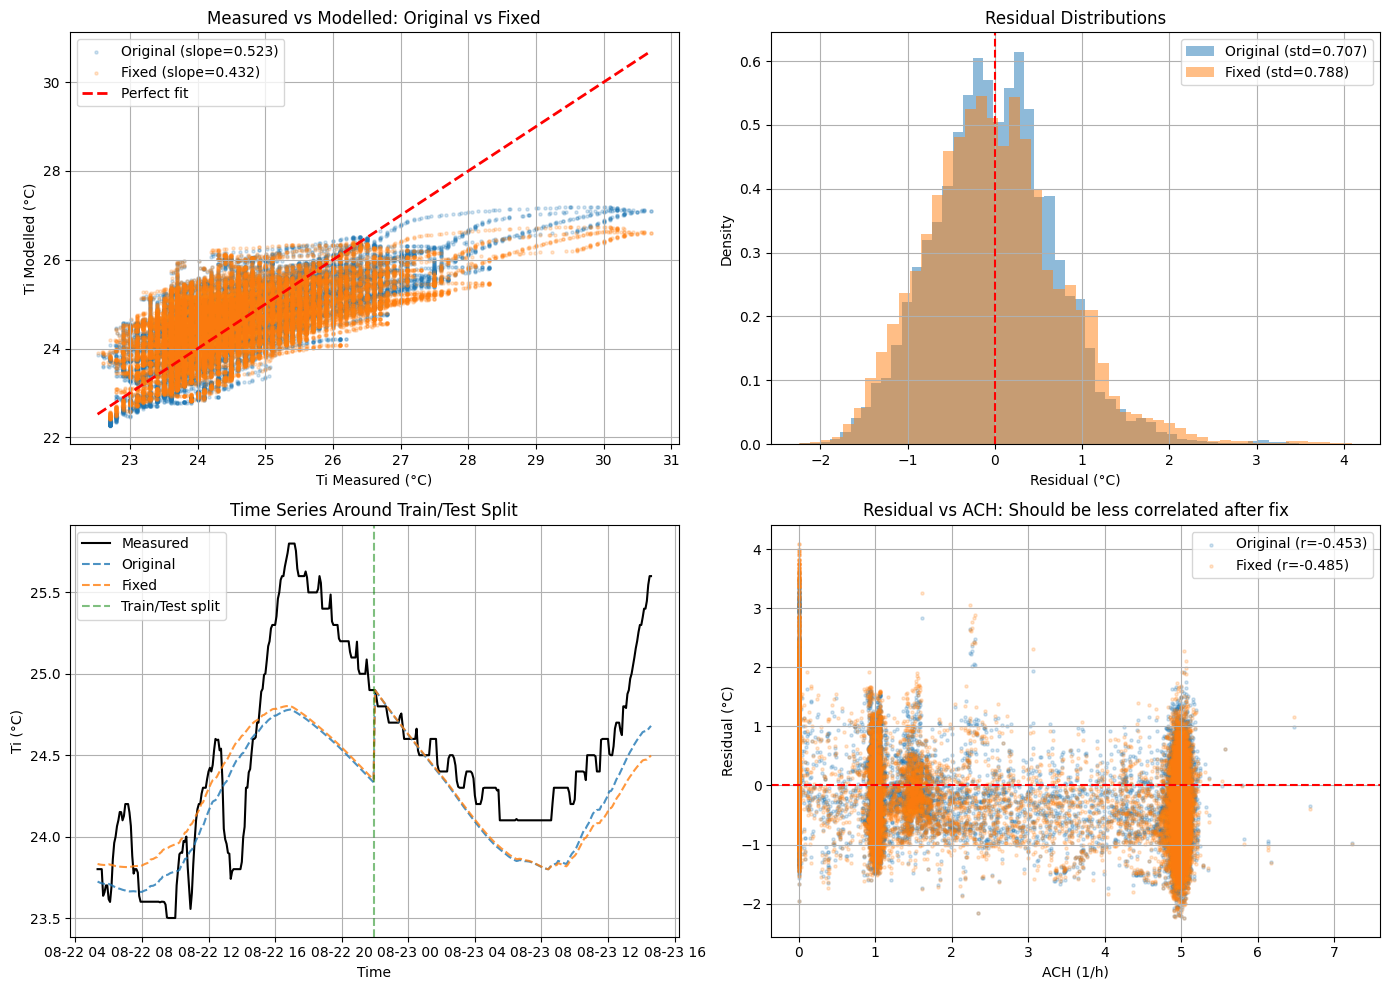

In [39]:
# Analyze responsiveness of fixed model
Ti_modelled_fixed = np.concatenate([train_results_fixed.Z, test_results_fixed.Z])
residuals_fixed = Ti_measured - Ti_modelled_fixed

slope_fixed, intercept_fixed, r_value_fixed, _, _ = stats.linregress(Ti_measured, Ti_modelled_fixed)

print(f"\n--- RESPONSIVENESS COMPARISON ---")
print(f"Original model:")
print(f"  Slope: {slope:.4f} (captures {slope*100:.1f}% of variation)")
print(f"  R²: {r_value**2:.4f}")
print(f"\nFixed model (Q_vent=0):")
print(f"  Slope: {slope_fixed:.4f} (captures {slope_fixed*100:.1f}% of variation)")
print(f"  R²: {r_value_fixed**2:.4f}")

improvement = (slope_fixed - slope) / slope * 100
print(f"\n  Improvement in responsiveness: {improvement:+.1f}%")

# Compare fitted parameters
print(f"\n--- FITTED PARAMETERS COMPARISON ---")
print(f"{'Parameter':<15} {'Original':>15} {'Fixed':>15} {'Change':>15}")
print("-" * 60)
for name in ['Ci', 'Ch', 'Rint', 'Rout', 'tau_v']:
    orig_val = model_kf.result.params[name].value
    fixed_val = model_kf_fixed.result.params[name].value
    change = (fixed_val - orig_val) / orig_val * 100 if orig_val != 0 else 0
    print(f"{name:<15} {orig_val:>15.4g} {fixed_val:>15.4g} {change:>+14.1f}%")

# Visualize comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Measured vs Modelled comparison
axes[0, 0].scatter(Ti_measured, Ti_modelled, alpha=0.2, s=5, label=f'Original (slope={slope:.3f})')
axes[0, 0].scatter(Ti_measured, Ti_modelled_fixed, alpha=0.2, s=5, label=f'Fixed (slope={slope_fixed:.3f})')
axes[0, 0].plot([Ti_measured.min(), Ti_measured.max()], 
                [Ti_measured.min(), Ti_measured.max()], 'r--', label='Perfect fit', linewidth=2)
axes[0, 0].set_xlabel('Ti Measured (°C)')
axes[0, 0].set_ylabel('Ti Modelled (°C)')
axes[0, 0].set_title('Measured vs Modelled: Original vs Fixed')
axes[0, 0].legend()
axes[0, 0].grid(True)

# Plot 2: Residual histograms
axes[0, 1].hist(residuals, bins=50, alpha=0.5, label=f'Original (std={np.std(residuals):.3f})', density=True)
axes[0, 1].hist(residuals_fixed, bins=50, alpha=0.5, label=f'Fixed (std={np.std(residuals_fixed):.3f})', density=True)
axes[0, 1].axvline(x=0, color='r', linestyle='--')
axes[0, 1].set_xlabel('Residual (°C)')
axes[0, 1].set_ylabel('Density')
axes[0, 1].set_title('Residual Distributions')
axes[0, 1].legend()
axes[0, 1].grid(True)

# Plot 3: Time series comparison (sample)
sample_start = len(y_train) - 200
sample_end = len(y_train) + 200
sample_idx = idx[sample_start:sample_end]
axes[1, 0].plot(sample_idx, Ti_measured[sample_start:sample_end], 'k-', label='Measured', linewidth=1.5)
axes[1, 0].plot(sample_idx, Ti_modelled[sample_start:sample_end], '--', label='Original', alpha=0.8)
axes[1, 0].plot(sample_idx, Ti_modelled_fixed[sample_start:sample_end], '--', label='Fixed', alpha=0.8)
axes[1, 0].axvline(x=y_train.index[-1], color='g', linestyle='--', alpha=0.5, label='Train/Test split')
axes[1, 0].set_xlabel('Time')
axes[1, 0].set_ylabel('Ti (°C)')
axes[1, 0].set_title('Time Series Around Train/Test Split')
axes[1, 0].legend()
axes[1, 0].grid(True)

# Plot 4: Residual vs ACH (should be less correlated now)
ACH_full = input_df.loc[idx, 'ACH'].values
corr_orig, _ = stats.pearsonr(ACH_full, residuals)
corr_fixed, _ = stats.pearsonr(ACH_full, residuals_fixed)

axes[1, 1].scatter(ACH_full, residuals, alpha=0.2, s=5, label=f'Original (r={corr_orig:.3f})')
axes[1, 1].scatter(ACH_full, residuals_fixed, alpha=0.2, s=5, label=f'Fixed (r={corr_fixed:.3f})')
axes[1, 1].axhline(y=0, color='r', linestyle='--')
axes[1, 1].set_xlabel('ACH (1/h)')
axes[1, 1].set_ylabel('Residual (°C)')
axes[1, 1].set_title('Residual vs ACH: Should be less correlated after fix')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================================
# ALTERNATIVE FIX: Correct Q_vent formula using actual supply temperature
# ============================================================================
print("=" * 70)
print("ALTERNATIVE FIX: CORRECTING Q_VENT FORMULA")
print("=" * 70)

print("""
Removing Q_vent made things WORSE. This means ventilation is an important
effect, but the formula is wrong.

Current formula:  Q_vent = rho*cp*Q * (20 - Ti)  [uses fixed 20°C reference]
Corrected formula: Q_vent = rho*cp*Q * (Ta - Ti)  [uses actual outdoor temp]

The corrected formula properly represents:
- Positive Q_vent when Ta > Ti (heating from warm outdoor air)
- Negative Q_vent when Ta < Ti (cooling from cold outdoor air)
""")

# Create corrected Q_vent
rho_cp = 1.2 * 1000  # J/m³·K
Q_flow = input_df['Q']  # m³/h
Ta = input_df['Ta']
Ti = input_df['Ti']
svent = input_df['svent']

# Corrected formula using outdoor air temperature
input_df_corrected = input_df.copy()
input_df_corrected['Q_vent'] = svent * rho_cp * Q_flow * (Ta - Ti) / 3600  # W

print("Original Q_vent statistics:")
print(f"  Mean: {input_df['Q_vent'].mean():.1f} W")
print(f"  Range: [{input_df['Q_vent'].min():.1f}, {input_df['Q_vent'].max():.1f}] W")

print("\nCorrected Q_vent statistics:")
print(f"  Mean: {input_df_corrected['Q_vent'].mean():.1f} W")
print(f"  Range: [{input_df_corrected['Q_vent'].min():.1f}, {input_df_corrected['Q_vent'].max():.1f}] W")

# Recreate input data
input_X_corrected = input_df_corrected[['Ta', 'Tfor', 'Q_vent', 'Q_solar', 'MVV', 'ACH', 'Ti0', 'Th0', 'xv0', 'C0', 'N0']]
X_train_corrected, X_test_corrected, _, _ = train_test_split(input_X_corrected, input_y, test_size=0.2, shuffle=False)

# For KF model
input_df_corrected['C_obs'] = input_df_corrected['C']
input_df_corrected['P_N0'] = 1.0
input_X_kf_corrected = input_df_corrected[['Ta', 'Tfor', 'Q_vent', 'Q_solar', 'MVV', 'ACH', 'Ti0', 'Th0', 'xv0', 'C0', 'N0', 'C_obs', 'P_N0']]
X_train_kf_corrected, X_test_kf_corrected, _, _ = train_test_split(input_X_kf_corrected, input_y, test_size=0.2, shuffle=False)

print("\n✓ Created corrected datasets with Q_vent = rho*cp*Q*(Ta-Ti)/3600")

In [ ]:
# Re-train with corrected Q_vent
print("Training model with CORRECTED Q_vent formula...")

models_kf_corrected = [TiTmxvCN2R2C_KF(train_params_KF, rec_duration)]

df_kf_corrected = darkgreyfit(
    models=models_kf_corrected,
    X_train=X_train_kf_corrected,
    y_train=y_train,
    X_test=X_test_kf_corrected,
    y_test=y_test,
    ic_params_map=ic_params_map_kf,
    error_metric=error_metric,
    prefit_filter=None,
    prefit_splits=None,
    n_jobs=1
)

print("Training complete!")

# Extract results
select_idx_corrected = df_kf_corrected[('train', 'error')].argmin()
model_kf_corrected = df_kf_corrected.loc[select_idx_corrected, ('train', 'model')]
train_results_corrected = df_kf_corrected.loc[select_idx_corrected, ('train', 'model_result')]
test_results_corrected = df_kf_corrected.loc[select_idx_corrected, ('test', 'model_result')]

# Analyze
Ti_modelled_corrected = np.concatenate([train_results_corrected.Z, test_results_corrected.Z])
residuals_corrected = Ti_measured - Ti_modelled_corrected
slope_corrected, intercept_corrected, r_value_corrected, _, _ = stats.linregress(Ti_measured, Ti_modelled_corrected)

print(f"\n{'='*70}")
print("FINAL COMPARISON: All Three Approaches")
print(f"{'='*70}")
print(f"\n{'Model':<25} {'Train RMSE':>12} {'Test RMSE':>12} {'Slope':>10} {'R²':>10}")
print("-" * 70)
print(f"{'Original (20-Ti)':<25} {df_kf.loc[select_idx_kf, ('train', 'error')]:>12.4f} {df_kf.loc[select_idx_kf, ('test', 'error')]:>12.4f} {slope:>10.4f} {r_value**2:>10.4f}")
print(f"{'Q_vent = 0':<25} {df_kf_fixed.loc[select_idx_fixed, ('train', 'error')]:>12.4f} {df_kf_fixed.loc[select_idx_fixed, ('test', 'error')]:>12.4f} {slope_fixed:>10.4f} {r_value_fixed**2:>10.4f}")
print(f"{'Corrected (Ta-Ti)':<25} {df_kf_corrected.loc[select_idx_corrected, ('train', 'error')]:>12.4f} {df_kf_corrected.loc[select_idx_corrected, ('test', 'error')]:>12.4f} {slope_corrected:>10.4f} {r_value_corrected**2:>10.4f}")

# Best model?
rmse_orig = df_kf.loc[select_idx_kf, ('test', 'error')]
rmse_fixed = df_kf_fixed.loc[select_idx_fixed, ('test', 'error')]
rmse_corrected = df_kf_corrected.loc[select_idx_corrected, ('test', 'error')]

best = min([('Original', rmse_orig, slope), ('Q_vent=0', rmse_fixed, slope_fixed), ('Corrected', rmse_corrected, slope_corrected)], key=lambda x: x[1])
print(f"\n🏆 Best Test RMSE: {best[0]} ({best[1]:.4f}°C)")

best_resp = max([('Original', slope), ('Q_vent=0', slope_fixed), ('Corrected', slope_corrected)], key=lambda x: x[1])
print(f"🏆 Best Responsiveness: {best_resp[0]} (slope={best_resp[1]:.4f})")